In [ ]:
# Main packages
import polars as pl
import numpy as np
import matplotlib.pyplot as plt

In [4]:
# Time constants
MINUTES_PER_WEEK = 7 * 24 * 60
N_WEEKS = 8
EIGHT_WEEKS_SECONDS = N_WEEKS * MINUTES_PER_WEEK * 60

In [ ]:
# Load data
df = pl.scan_csv("/home/lanl/data/cyber1/auth.txt.gz", has_header=False, separator=",",
                 new_columns=['time','src_user','dest_user','src_comp','dest_comp',
                              'auth_type','logon_type','auth_orientation','outcome'])

In [5]:
# Keep only human users
df = df.filter(pl.col('src_user').str.starts_with('U'))

In [ ]:
# Keep the first 8 weeks of data
df = df.filter(pl.col('time') < EIGHT_WEEKS_SECONDS)

In [7]:
# Distinct (user, minute) activity points — the finest resolution needed;
# all aggregation levels are derived from this by integer division
user_minutes = (
    df.select(
        'src_user',
        minute = pl.col('time') // 60,
    )
    .unique()
    .collect(engine='streaming')
)

# Functions

In [8]:
def jaccard_by_week(AGG_HOURS):

    AGG_MINUTES = round(AGG_HOURS * 60)   # exact integers, e.g. 1/6 h -> 10

    # Each activity point: which week it is in, and its position within the week
    points = (
        user_minutes.select(
            'src_user',
            week = pl.col('minute') // MINUTES_PER_WEEK,
            relative_bucket = (pl.col('minute') % MINUTES_PER_WEEK) // AGG_MINUTES,
        )
        .unique()
    )

    jaccards = []

    for week in range(N_WEEKS - 1):

        w_curr = points.filter(pl.col('week') == week)
        w_next = points.filter(pl.col('week') == week + 1)

        overlap = w_curr.join(w_next, on=['src_user', 'relative_bucket'], how='inner')

        union = len(w_curr) + len(w_next) - len(overlap)

        jaccards.append(len(overlap) / union)

    return np.array(jaccards)

In [ ]:
# Aggregation levels in hours (1 week = the user-persistence limit)
levels = {'1 min': 1/60, '10 min': 1/6, '30 min': 0.5, '1 h': 1, '2 h': 2,
          '3 h': 3, '4 h': 4, '6 h': 6, '8 h': 8, '12 h': 12,
          '24 h': 24, '1 week': 168}

In [10]:
results = {name: jaccard_by_week(h) for name, h in levels.items()}

In [14]:
for name, js in results.items():
    print(f"{name:>7}:  mean {js.mean():.3f}   sd {js.std(ddof=1):.3f}")

  1 min:  mean 0.160   sd 0.013
 10 min:  mean 0.304   sd 0.014
 30 min:  mean 0.469   sd 0.021
    1 h:  mean 0.596   sd 0.030
    2 h:  mean 0.639   sd 0.039
    3 h:  mean 0.631   sd 0.038
    4 h:  mean 0.625   sd 0.036
    6 h:  mean 0.617   sd 0.035
    8 h:  mean 0.613   sd 0.034
   12 h:  mean 0.596   sd 0.032
   24 h:  mean 0.589   sd 0.028
 1 week:  mean 0.711   sd 0.020


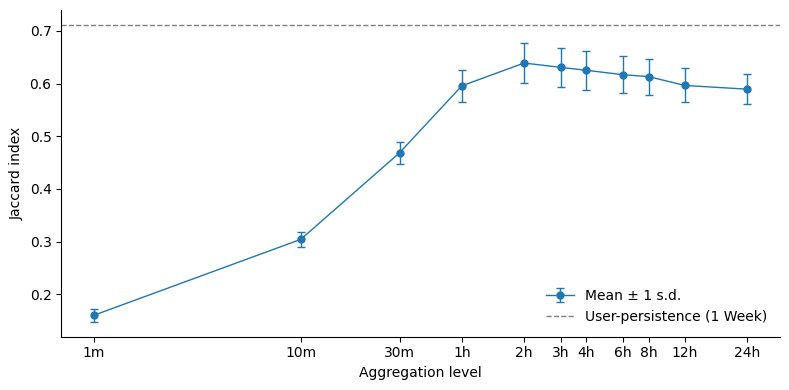

In [48]:
# Plot
fig, ax = plt.subplots(figsize=(8, 4))

curve_hours = np.array([h for name, h in levels.items() if name != '1 week'])
curve_values = [results[name] for name in levels if name != '1 week']

means = np.array([js.mean() for js in curve_values])
sds = np.array([js.std(ddof=1) for js in curve_values])

ax.errorbar(curve_hours, means, yerr=sds, marker='o', ms=5, lw=1,
            color='tab:blue', capsize=3, elinewidth=1,
            label='Mean ± 1 s.d.')

persistence = results['1 week'].mean()
ax.axhline(persistence, ls='--', lw=1, color='grey',
           label='User-persistence (1 Week)')

ax.set_xscale('log')
ax.set_xticks(curve_hours)
ax.set_xticklabels(['1m','10m','30m','1h','2h','3h','4h','6h','8h','12h','24h'])
ax.minorticks_off()
ax.set_xlabel('Aggregation level')
ax.set_ylabel('Jaccard index')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], frameon=False, loc='lower right')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()

plt.savefig('jaccard_plot.pdf', format='pdf')